In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df = pd.read_csv(url, sep=';')

X = df.drop('quality', axis=1)
y = df['quality']

print(f"Wymiary zbioru: {df.shape}")

Wymiary zbioru: (4898, 12)


# Zadanie 1

Wybierz 4 cechy ze zbioru numer 1 o najwyższej wariancji i wyświetl ich rozkłady korzystając z przykładu w sekcji 1 wykładu numer 6.

4 cechy o najwyższej wariancji to: ['total sulfur dioxide', 'free sulfur dioxide', 'residual sugar', 'alcohol']


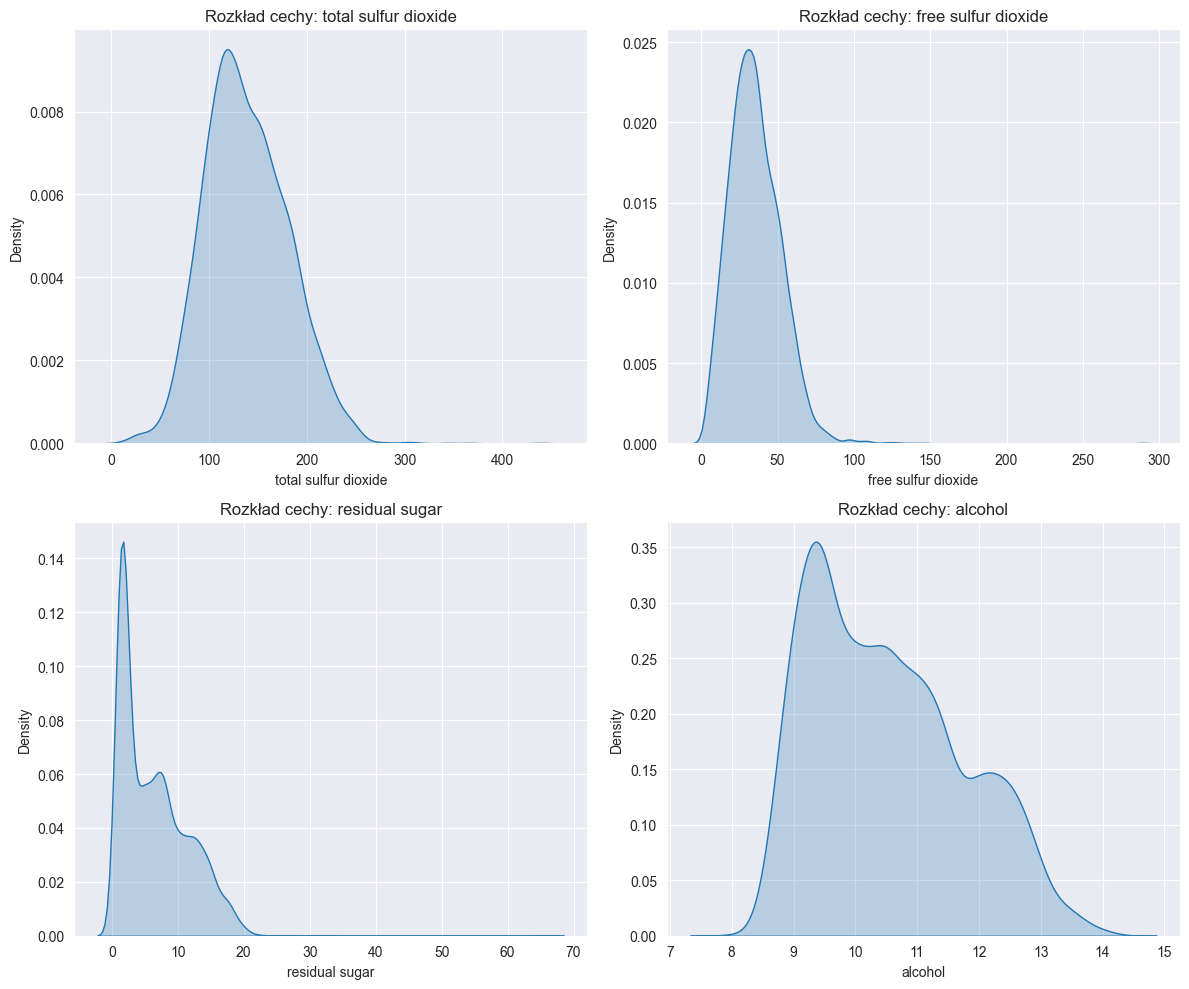

In [2]:
# wariancja dla każdej kolumny i sort mal
variances = X.var().sort_values(ascending=False)

top_4_features = variances.head(4).index.tolist()
print(f"4 cechy o najwyższej wariancji to: {top_4_features}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, feature in zip(axes.flatten(), top_4_features):
    sns.kdeplot(data=df, x=feature, ax=ax, fill=True)
    ax.set_title(f"Rozkład cechy: {feature}")

plt.tight_layout()
plt.show()

# Zadanie 2

Napisz funkcję, która będzie służyła do wykrywania czy dana cecha ramki danych posiada wartości odstające wyliczane metodą rozstępu międzyćwiartowego. Możesz zaimplementować wyliczanie ćwiartek na piechotę lub wykorzystać do tego bibliotekę pandas i/lub numpy, scikit-learn. Funkcja przyjmuje ramkę danych jako parametr wejściowy, a zwraca listę cech (kolumn), które zawierają wartości odstające.

In [3]:
def detect_outliers_iqr(data):

    outlier_columns = []

    numeric_cols = data.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if ((data[col] < lower_bound) | (data[col] > upper_bound)).any():
            outlier_columns.append(col)

    return outlier_columns

kolumny_z_outlierami = detect_outliers_iqr(X)
print("Cechy z wartosciami odstającymi:")
print(kolumny_z_outlierami)

Cechy z wartosciami odstającymi:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']


# Zadanie 3

Wykorzystaj zbiór danych 1 i stwórz model klasyfikacji wykorzystując kod z sekcji 1.1 wykładu numer 6. Wykorzystaj wszystkie 4 podejścia (brak skalowania, standaryzacja, skalowanie min-max, skalowanie robust) i wyświetl wyniki dla metryki accuracy (jak w przykładzie).

Wytyczne:

- skalujemy wszystkie cechy
- pamiętaj o ochronie przed wyciekiem danych

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipelines = {
    "1. Brak skalowania": KNeighborsClassifier(),

    "2. StandardScaler": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),

    "3. MinMaxScaler": Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier())
    ]),

    "4. RobustScaler": Pipeline([
        ('scaler', RobustScaler()),
        ('knn', KNeighborsClassifier())
    ])
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Dokładność ({name}): {acc:.4f}")

Dokładność (1. Brak skalowania): 0.4827
Dokładność (2. StandardScaler): 0.5429
Dokładność (3. MinMaxScaler): 0.5531
Dokładność (4. RobustScaler): 0.5480


# Zadanie 4

Wykorzystaj funkcję z zadania numer 2 do wskazania cech, które ze względu na występujące (lub może nie) wartości odstające, kwalifikują się do poddania ich skalowaniu. Przeskaluj tylko te cechy i wytrenuj model zgodnie z kodem z zadania 3 (de facto odfiltrowujemy tylko cechy przed uruchomieniem całego pipeline-u).

Porównaj wyniki z uzyskanymi w zadaniu numer 3. Odpowiedz:

Czy sam fakt występowania wartości odstających jest wskazówką do przeprowadzenia skalowania danych?
Czy obecność wartości odstających może być czynnikiem decyzyjnym w kontekście zastosowania konkretnej metody skalowania danych?
Jaki inny czynnik wsytępujący w danych może kwalifikować cechę do poddania jej skalowaniu?

In [5]:
outlier_features = detect_outliers_iqr(X_train)


preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), outlier_features)
    ],
    remainder='passthrough'
)
pipe_partial_scaling = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

pipe_partial_scaling.fit(X_train, y_train)
y_pred_partial = pipe_partial_scaling.predict(X_test)
acc_partial = accuracy_score(y_test, y_pred_partial)

print(f"Dokładność po przeskalowaniu TYLKO cech z outlierami: {acc_partial:.4f}")

Dokładność po przeskalowaniu TYLKO cech z outlierami: 0.5643


## Czy sam fakt występowania wartości odstających jest wskazówką do przeprowadzenia skalowania danych?
Nie. Sam fakt istnienia wartości odstających sugeruje, że dane mogą wymagać oczyszczenia (lub użycia odpowiedniej metryki odpornej) ale nie zmusza nas bezpośrednio do skalowania. O konieczności skalowania decyduje przede wszystkim typ wybranego algorytmu. Algorytmy oparte na odległości (np. k-NN, SVM) oraz na gradiencie (Sieci Neuronowe) potrzebują skalowania. Ale algorytmy oparte na drzewach decyzyjnych (Random Forest, XGBoost) poradzą sobie bez żadnego skalowania, nawet przy obecności wartości odstających.


## Czy obecność wartości odstających może być czynnikiem decyzyjnym w kontekście zastosowania konkretnej metody skalowania danych?
Tak. Jeśli wiemy, że nasz zbiór zawiera ekstremalne wartości odstające, zastosowanie klasycznego MinMaxScaler ściśnie większość "normalnych" danych blisko zera, a StandardScaler przesunie średnią, zafałszowując statystykę. W takich przypadkach obecność outlierów jest bezpośrednim czynnikiem decydującym o użyciu RobustScaler (który ignoruje wartości skrajne, bazując na medianie i rozstępie IQR).


## Jaki inny czynnik wsytępujący w danych może kwalifikować cechę do poddania jej skalowaniu?
Głównym czynnikiem jest rząd wielkości i jednostki poszczególnych cech (zakres wartości). Jeśli jedna cecha jest wyrażona w ułamkach (np. stężenie kwasu: 0.02 - 0.08), a inna idzie w tysiące (np. dochód 10000 - 150000 lub w winach zawartość dwutlenku siarki np. 100 - 300), to bez przeskalowania matematyka modelu (odległość euklidesowa) całkowicie zignoruje cechę ułamkową, traktując ją jako błąd zaokrąglenia wobec cechy o rzędzie tysięcy. Standaryzacja wyrównuje "ważność" obu cech.